In [3]:
#cargamos las librerias necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
#cargamos el dataset

df = pd.read_csv('../dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [5]:
#revision exploratoria de los datos
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
#se revisa el tamaño del dataset
df.shape

(7043, 21)

In [7]:
#se revisa los tipos de datos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [8]:
#revisemos el nombre de las columnas
df.columns.to_list()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [9]:
#revision de nulos
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
#convertir la columna TotalCharges a tipo numerico
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

#revisar los valores nulos nuevamente
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [11]:
#vamos a revisar si hay valores duplicados
df.duplicated().sum()

np.int64(0)

In [12]:
#contamos los valores de la columna Churn
df['Churn'].value_counts()

#veamos en porcentajes la cantidad que clientes que se fueron y los que se quedaron
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

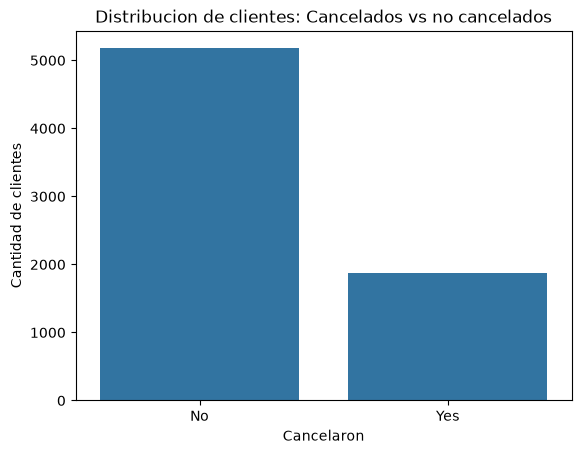

In [13]:
#visualicemos la columna Churn con un grafico de barras

sns.countplot(x='Churn',data=df)
plt.title('Distribucion de clientes: Cancelados vs no cancelados')
plt.xlabel('Cancelaron')
plt.ylabel('Cantidad de clientes')
plt.show()


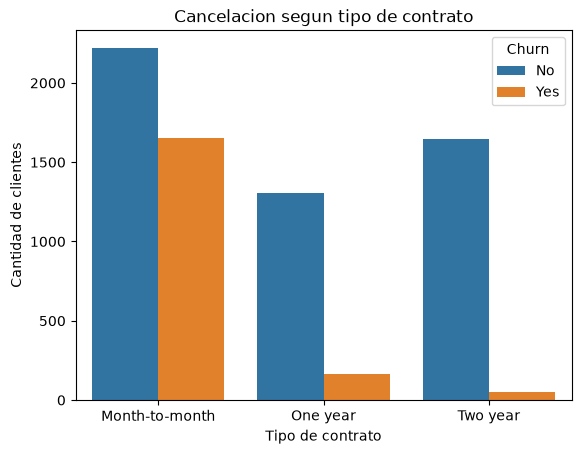

In [14]:
#vamos a revisar la relacion entre tipo de contrato y la cancelacion del servicio
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Cancelacion segun tipo de contrato')
plt.xlabel('Tipo de contrato')
plt.ylabel('Cantidad de clientes')
plt.show()


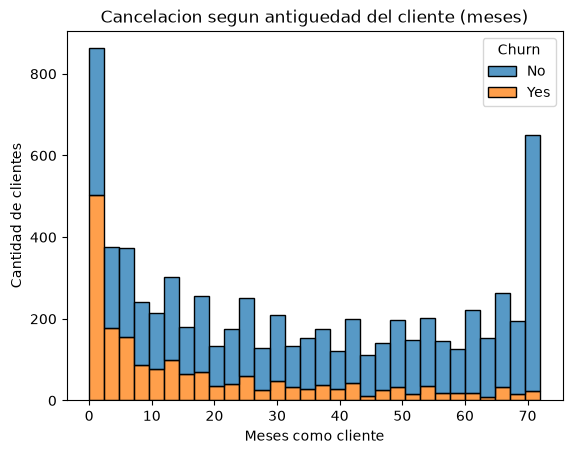

In [15]:
#vamos a revisar la realcion entre antiguedad del cliente y la cancelacion del servicio
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', bins=30)
plt.title('Cancelacion segun antiguedad del cliente (meses)')
plt.xlabel('Meses como cliente')
plt.ylabel('Cantidad de clientes')
plt.show()

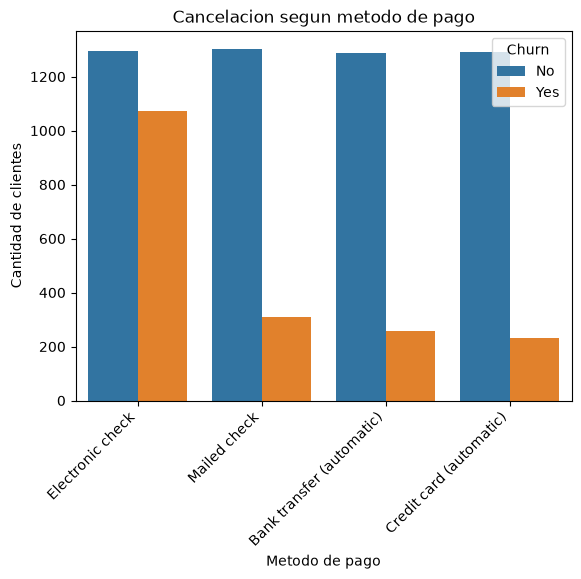

In [16]:
#vamos a revisar la relacion entre metodo de pago y cancelacion del servicio
sns.countplot(data=df, x='PaymentMethod', hue='Churn')
plt.title('Cancelacion segun metodo de pago')
plt.xlabel('Metodo de pago')
plt.ylabel('Cantidad de clientes')
plt.xticks(rotation=45, ha='right')
plt.show()

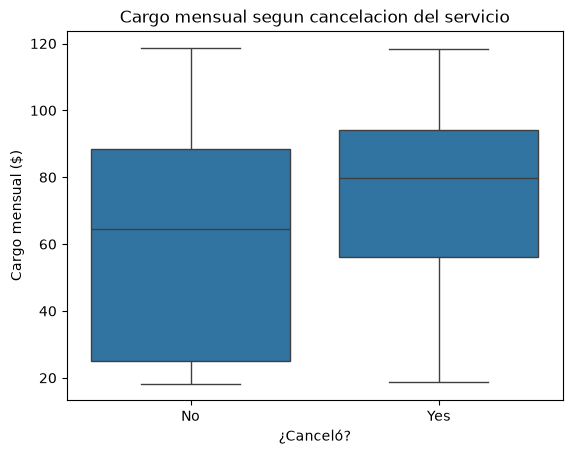

In [17]:
#cargo mensual vs cancelacion del servicio
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title('Cargo mensual segun cancelacion del servicio')
plt.xlabel('¿Canceló?')
plt.ylabel('Cargo mensual ($)')
plt.show()

## Resumen del Análisis Exploratorio (EDA)

### Dataset
- Total de clientes analizados: 7,032 (después de limpieza)
- Columnas: 21 (20 variables predictoras + 1 variable objetivo `Churn`)

### Calidad de los datos
- Se encontraron 11 valores faltantes en `TotalCharges` (venían como texto vacío).
- Se eliminaron esas filas por representar menos del 0.2% del dataset.
- No se encontraron filas duplicadas.

### Variable objetivo (Churn)
- 73.5% de los clientes NO cancelaron.
- 26.5% de los clientes SÍ cancelaron.
- Existe un desbalance moderado de clases, que se tendrá en cuenta
  en la Fase 2 usando métricas como F1-score y recall (no solo accuracy).

### Principales patrones encontrados
- Los clientes con contrato "mes a mes" cancelan significativamente más
  que los de contrato anual o bianual.
- La cancelación es más frecuente en clientes nuevos (baja antigüedad/tenure).
- Los clientes que pagan con "Electronic check" cancelan más que los que
  tienen pago automático.
- Los clientes con cargos mensuales más altos tienden a cancelar más.
- La falta de servicios adicionales (como soporte técnico) se asocia
  con mayor cancelación.

### Conclusión
El tipo de contrato, la antigüedad del cliente y el método de pago
parecen ser las variables con mayor relación con la cancelación.
Estas variables serán clave para el modelo predictivo de la Fase 2.

In [18]:
#vamos a guardar el dataset limpio en un nuevo archivo CSV
df.to_csv('../dataset/telco_churn_clean.csv', index=False)